# Momentum Growth Strategy — GPW 2015–2025
Comparison of three momentum/growth strategy variants on Warsaw Stock Exchange data.

**Results, visualizations and animations ready for article / YouTube.**


---
## Algorithm Description

### General Idea

The strategy belongs to the **momentum/growth** class — we buy stocks that have risen recently (assuming trend continuation) and sell those that have clearly stalled. We do not try to predict the future — we react to price signals from three time horizons simultaneously.

---

### 1. Scoring — How Do We Evaluate a Stock?

For each stock and each month we compute a **point score** (0–6 pts) based on three return rates:

| Horizon | Formula | Max points |
|---------|---------|-----------|
| 1M      | 1%–10%  | 3 pts     |
| 12M     | 5%–30%  | 2 pts     |
| 36M     | 20%–120%| 1 pt      |

Percentage score = `score / 6 × 100`

---

### 2. Portfolio Selection (monthly)

1. Rank all stocks by score (descending)
2. **Buy:** top N stocks with score > entry threshold
3. **Hold:** keep if score > exit threshold
4. **Sell:** score drops below exit threshold

**Capital allocation:** equal-weight across all held positions.

**No lookahead bias:** the score is computed from prices up to the end of month *t*, and the resulting trades are executed at month *t+1* prices — the first point at which we could realistically act on the signal.

---

### 3. Position Management

- **Stop-loss:** none (pure scoring-based exit)
- **Belka tax (19% capital gains tax):** charged on each profitable sale
- **Rebalancing:** monthly — signal from prior month-end, execution at the following month-end price

---

### 4. Three Strategy Variants

| Variant | Entry | Exit | Max positions |
|---------|-------|------|---------------|
| S1 Monthly rebalance | 50%  | 33%  | 10            |
| S2 Minimal rebalance | 60%  | 25%  | 10            |
| S3 Wide corridor     | 40%  | 20%  | 15            |

---

### 5. Model Limitations

- No slippage modelled (assumes execution at month-end prices)
- Signal-to-execution lag of one month removes lookahead bias but does not model intra-month price moves
- GPW-specific — may not generalise to other markets
- Backtest covers 2015–2025 (10 years); survivorship bias possible (universe = stocks listed today)
- Tax calculated per transaction (realistic Polish tax treatment)

---

*Analysis and code: Python + Claude AI*


## 0. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Output folder ──────────────────────────────────────────────────────
OUT = Path('charts')
OUT.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 200,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLORS = {'s1': '#E74C3C', 's2': '#3498DB', 's3': '#2ECC71', 'neutral': '#95A5A6'}
print('Setup OK — wykresy zapisywane do:', OUT.resolve())


Setup OK — wykresy zapisywane do: D:\MOJE\PROJEKTY\stock-technical-analysis\momentum-growth\charts


## 1. Load Data

In [2]:
df_raw = pd.read_csv('open_prices.csv', index_col='Date', parse_dates=True)
# forward-fill only: a missing price is carried from the past, never from the future.
# (bfill would pull future prices backward -> lookahead bias)
df_raw = df_raw.sort_index().ffill()

START_DATE = pd.Timestamp('2015-01-01')
END_DATE   = pd.Timestamp('2025-12-31')

df = df_raw.loc[START_DATE:END_DATE]
price_m = df.resample('M').last().dropna(axis=1, how='all')

print(f'Zakres dat:    {price_m.index[0].date()} – {price_m.index[-1].date()}')
print(f'Liczba miesięcy: {len(price_m)}')
print(f'Liczba spółek:   {price_m.shape[1]}')

Zakres dat:    2015-01-31 – 2025-09-30
Liczba miesięcy: 129
Liczba spółek:   351


## 2. Scoring System

| Horizon | Range   | Max points |
|---------|---------|-----------|
| 1M      | 1%–10%  | 3 pts     |
| 12M     | 5%–30%  | 2 pts     |
| 36M     | 20%–120%| 1 pt      |

Percentage score = `score / 6 × 100`

In [3]:
def compute_percent(price_m):
    r1  = (price_m / price_m.shift(1)  - 1) * 100
    r12 = (price_m / price_m.shift(12) - 1) * 100
    r36 = (price_m / price_m.shift(36) - 1) * 100
    s  = ((r1  - 1)  / 9  * 3).clip(0, 3)
    s += ((r12 - 5)  / 25 * 2).clip(0, 2)
    s += ((r36 - 20) / 100 * 1).clip(0, 1)
    return (s / 6 * 100)

percent_df = compute_percent(price_m)
print('Scoring OK, przykładowe wartości:')
print(percent_df.iloc[-3:, :5].round(1))


Scoring OK, przykładowe wartości:
            06N.WA  08N.WA  11B.WA  1AT.WA  3RG.WA
Date                                              
2025-07-31     0.0     0.0     0.0    38.6    95.9
2025-08-31     0.0     0.0     0.0    78.4    44.4
2025-09-30    44.1     9.5     0.0    36.6    95.2


## 3. Backtest Engine

In [4]:
def run_backtest(price_m, percent_df, cfg):
    """
    Uniwersalny silnik backtestu.

    Brak lookahead bias: decyzja podejmowana jest na podstawie scoringu
    z miesiąca `signal_date`, a transakcje wykonywane są po cenach
    następnego miesiąca (`trade_date`) — pierwszego momentu, w którym
    realnie moglibyśmy zareagować na sygnał.

    cfg: dict z kluczami:
        start_capital, max_size, enter_pct, sell_pct,
        tax_rate, rebalance_monthly
    """
    cash = cfg['start_capital']
    positions = {}   # ticker -> {shares, avg_cost}
    txns, tax_recs, cap_hist = [], [], []

    def buy(date, ticker, allocation, prices):
        nonlocal cash
        price = prices.get(ticker, np.nan)
        if np.isnan(price) or price <= 0: return
        shares = int(np.floor(min(allocation, cash) / price))
        if shares <= 0: return
        cost = shares * price
        cash -= cost
        if ticker in positions:
            p = positions[ticker]
            new_avg = (p['shares']*p['avg_cost'] + cost) / (p['shares'] + shares)
            p['shares'] += shares;  p['avg_cost'] = new_avg
        else:
            positions[ticker] = {'shares': shares, 'avg_cost': price}
        txns.append(dict(date=date, ticker=ticker, side='buy',
                         shares=shares, price=price, value=cost, tax=0))

    def sell(date, ticker, prices):
        nonlocal cash
        pos = positions.pop(ticker)
        price = prices.get(ticker, np.nan)
        if np.isnan(price): return
        proceeds = pos['shares'] * price
        gain = proceeds - pos['shares'] * pos['avg_cost']
        tax = round(cfg['tax_rate'] * gain, 2) if gain > 0 else 0.0
        cash += proceeds - tax
        txns.append(dict(date=date, ticker=ticker, side='sell',
                         shares=pos['shares'], price=price, value=proceeds, tax=tax))
        if tax > 0: tax_recs.append(dict(date=date, tax=tax))

    dates = list(percent_df.index)
    # iterujemy parami: sygnał z `signal_date`, egzekucja po cenach `trade_date`
    for signal_date, trade_date in zip(dates[:-1], dates[1:]):
        prices  = price_m.loc[trade_date].to_dict()   # ceny, po których handlujemy
        pcts    = percent_df.loc[signal_date].dropna() # sygnał znany na koniec poprz. miesiąca

        # --- SELL ---
        for t in list(positions):
            if t in pcts and pcts[t] < cfg['sell_pct']:
                sell(trade_date, t, prices)

        # --- TARGET LIST ---
        top = pcts[pcts >= cfg['enter_pct']].sort_values(ascending=False)
        target = list(top.index[:cfg['max_size']])
        # fallback — fill if too few candidates above threshold
        if len(target) < cfg['max_size']:
            rest = pcts.drop(index=[x for x in target if x in pcts.index])
            target += list(rest.sort_values(ascending=False).index)[:cfg['max_size']-len(target)]

        # --- MONTHLY REBALANCE (Strategia 1) ---
        if cfg.get('rebalance_monthly'):
            for t in [t for t in list(positions) if t not in target]:
                sell(trade_date, t, prices)
            port_val = cash + sum(positions[t]['shares']*prices.get(t,0) for t in positions)
            alloc = port_val / cfg['max_size']
            for t in target:
                if t in positions:  # sell partial to rebalance
                    cur_val = positions[t]['shares'] * prices.get(t,0)
                    if cur_val > alloc * 1.05:
                        sell(trade_date, t, prices)
                buy(trade_date, t, alloc, prices)
        else:
            # --- MINIMAL: buy new slots only ---
            slots = cfg['max_size'] - len(positions)
            new_t = [t for t in target if t not in positions][:slots]
            if new_t and cash > 0:
                per_slot = cash / max(slots, 1)
                for t in new_t:
                    buy(trade_date, t, per_slot, prices)
            # top-up underfunded
            if positions and cash > 1:
                mv = {t: positions[t]['shares']*prices.get(t,0) for t in positions}
                buy(trade_date, min(mv, key=mv.get), cash, prices)

        # --- CAPITAL SNAPSHOT ---
        total = cash + sum(positions[t]['shares']*prices.get(t,0) for t in positions)
        cap_hist.append(dict(date=trade_date, capital=total, cash=cash,
                             n_positions=len(positions)))

    cap_df  = pd.DataFrame(cap_hist).set_index('date')
    cap_df.index = pd.to_datetime(cap_df.index)
    txn_df  = pd.DataFrame(txns)
    tax_df  = pd.DataFrame(tax_recs)
    return cap_df, txn_df, tax_df

print('Silnik backtestowy gotowy.')

Silnik backtestowy gotowy.


## 4. Run — Three Strategies

In [5]:
COMMON = dict(start_capital=1_000, max_size=10, tax_rate=0.19)

configs = {
    'S1 Miesięczny rebalans': dict(**COMMON, enter_pct=99, sell_pct=90, rebalance_monthly=True),
    'S2 Minimalny rebalans':  dict(**COMMON, enter_pct=99, sell_pct=90, rebalance_monthly=False),
    'S3 Szeroki korytarz':    dict(**COMMON, enter_pct=70, sell_pct=30, rebalance_monthly=False),
}

results = {}
for name, cfg in configs.items():
    cap_df, txn_df, tax_df = run_backtest(price_m, percent_df, cfg)
    results[name] = dict(cap=cap_df, txn=txn_df, tax=tax_df, cfg=cfg)
    final = cap_df['capital'].iloc[-1]
    ntxn  = len(txn_df)
    ttax  = tax_df['tax'].sum() if not tax_df.empty else 0
    ret   = (final / cfg['start_capital'] - 1) * 100
    print(f'{name:<30} | Kapitał: {final:>8.0f} PLN | Zwrot: {ret:>+6.1f}% | Txn: {ntxn:>5} | Podatek: {ttax:>7.0f} PLN')


S1 Miesięczny rebalans         | Kapitał:     1771 PLN | Zwrot:  +77.1% | Txn:  1524 | Podatek:    1204 PLN


S2 Minimalny rebalans          | Kapitał:     2416 PLN | Zwrot: +141.6% | Txn:  1388 | Podatek:    1575 PLN
S3 Szeroki korytarz            | Kapitał:     8587 PLN | Zwrot: +758.7% | Txn:   207 | Podatek:     578 PLN


## 5. Visualizations

> All charts saved to folder `charts/`

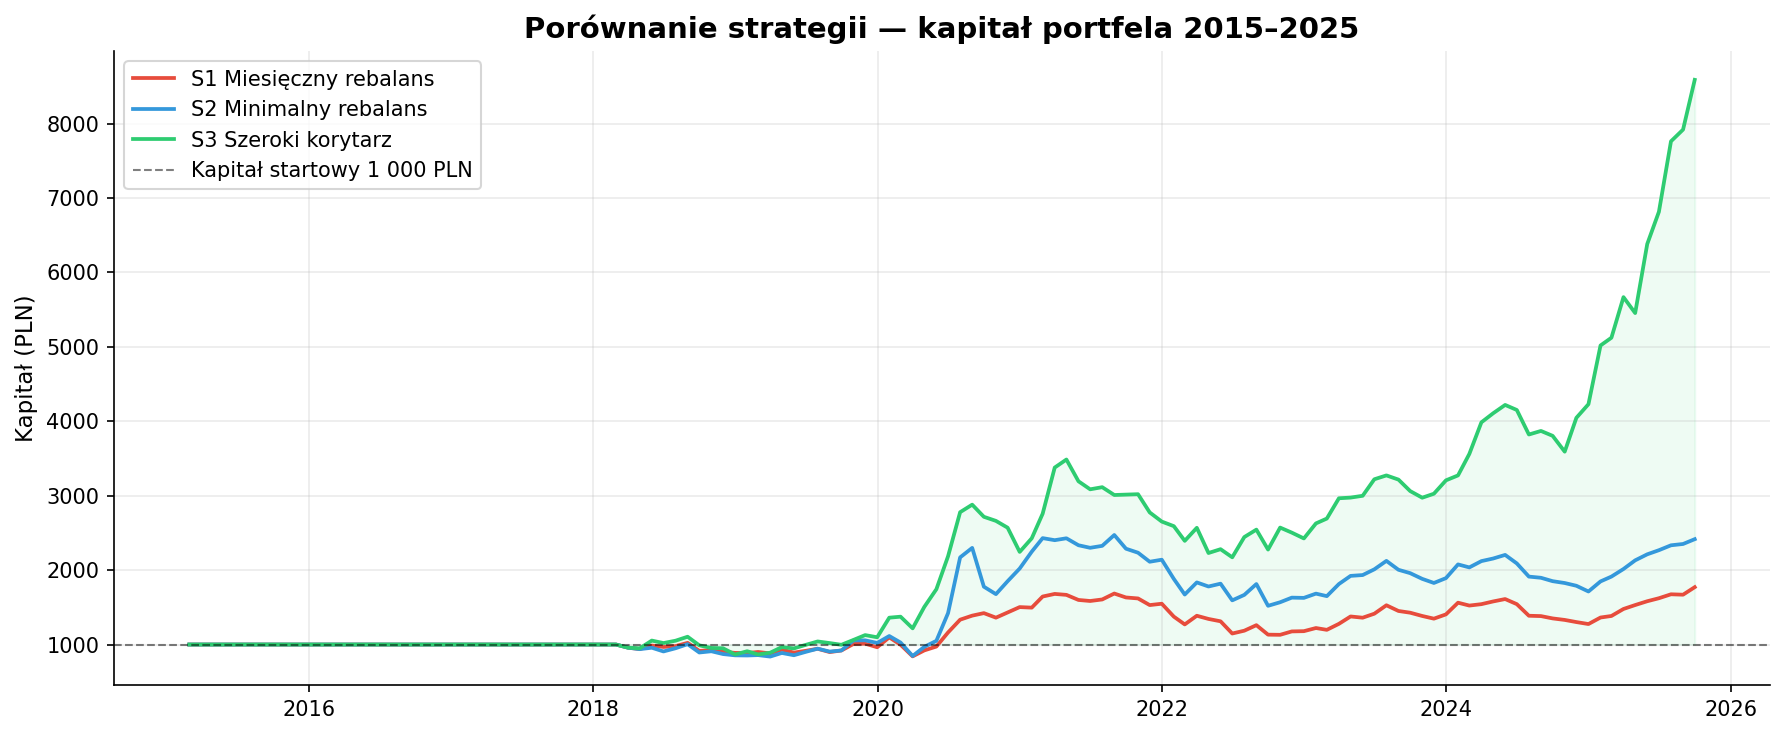

Saved: 01_kapital_porownanie.png


In [6]:
# ── Fig 1: Portfolio capital (all 3 strategies) ─────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
col_list = [COLORS['s1'], COLORS['s2'], COLORS['s3']]
for (name, res), col in zip(results.items(), col_list):
    ax.plot(res['cap'].index, res['cap']['capital'], label=name, color=col, linewidth=1.8)
ax.axhline(1000, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Kapitał startowy 1 000 PLN')
ax.set_title('Porównanie strategii — kapitał portfela 2015–2025', fontsize=14, fontweight='bold')
ax.set_ylabel('Kapitał (PLN)')
ax.legend()
ax.fill_between(list(results.values())[2]['cap'].index,
                list(results.values())[2]['cap']['capital'], 1000,
                alpha=0.08, color=COLORS['s3'])
plt.tight_layout()
fig.savefig(OUT / '01_kapital_porownanie.png', bbox_inches='tight')
plt.show()
print('Saved: 01_kapital_porownanie.png')


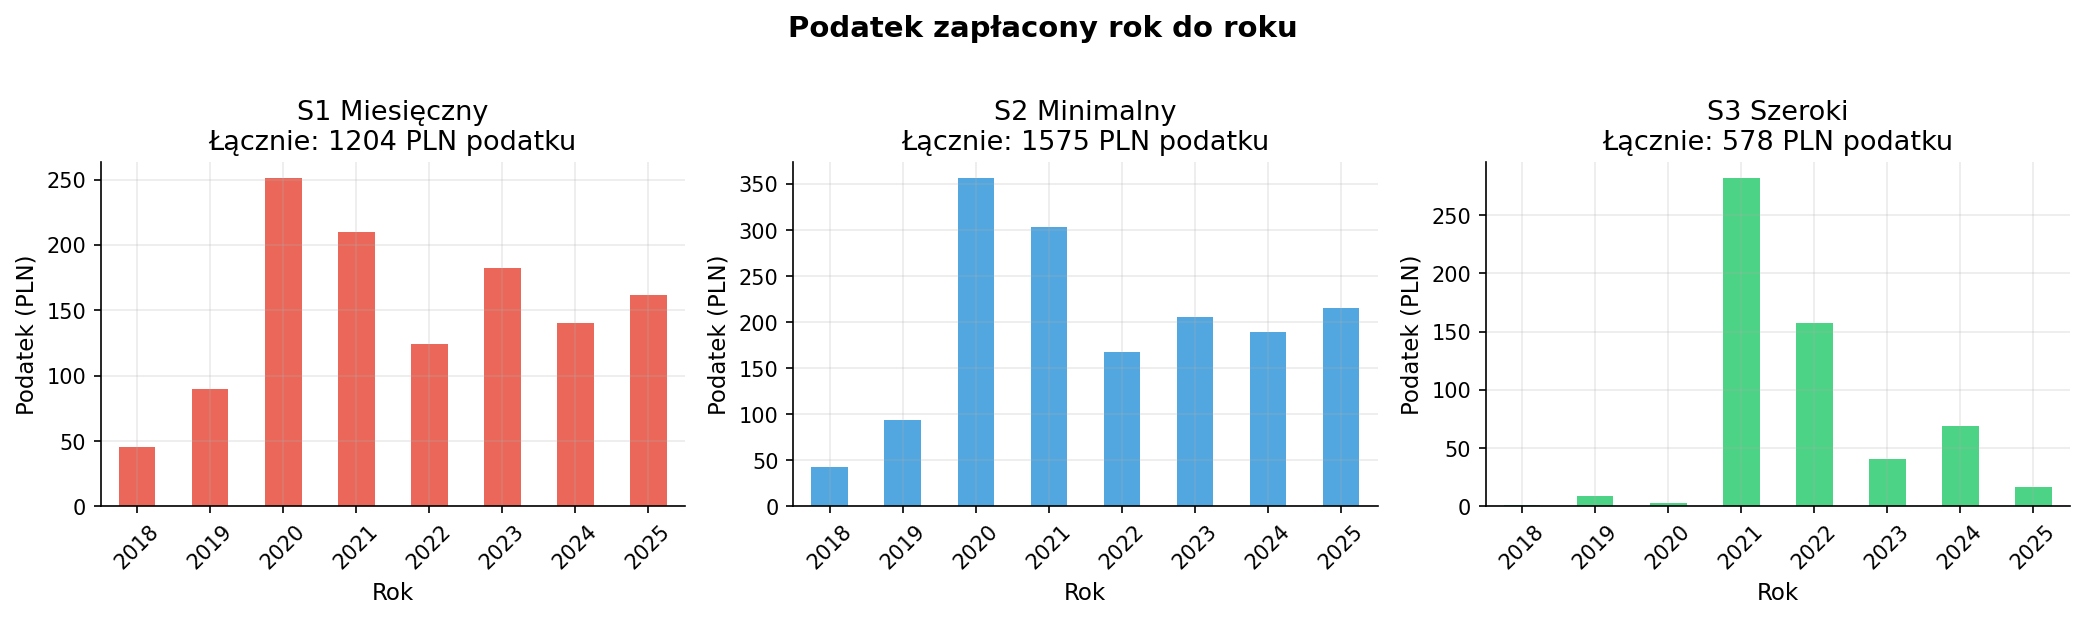

Saved: 02_podatki_roczne.png


In [7]:
# ── Fig 2: Transactions and taxes — overview ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
col_list = [COLORS['s1'], COLORS['s2'], COLORS['s3']]

for i, (name, res) in enumerate(results.items()):
    tax_df = res['tax']
    if not tax_df.empty:
        tax_df = tax_df.copy()
        tax_df['date'] = pd.to_datetime(tax_df['date'])
        by_year = tax_df.set_index('date').resample('Y')['tax'].sum()
        by_year.index = by_year.index.year
        by_year.plot(kind='bar', ax=axes[i], color=col_list[i], alpha=0.85)
    short = name.split()[0] + ' ' + name.split()[1]
    axes[i].set_title(f'{short}\nŁącznie: {tax_df["tax"].sum() if not tax_df.empty else 0:.0f} PLN podatku')
    axes[i].set_xlabel('Rok')
    axes[i].set_ylabel('Podatek (PLN)')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Podatek zapłacony rok do roku', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT / '02_podatki_roczne.png', bbox_inches='tight')
plt.show()
print('Saved: 02_podatki_roczne.png')


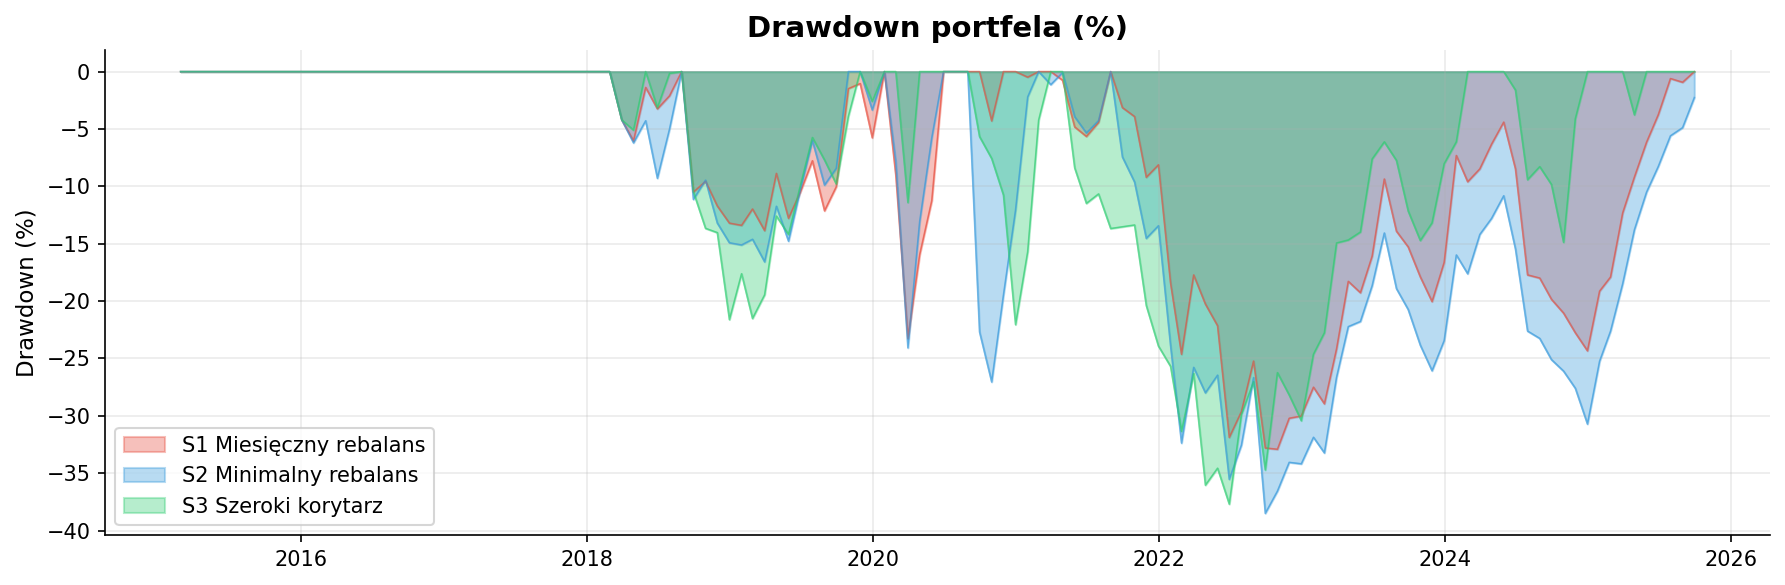

Saved: 03_drawdown.png


In [8]:
# ── Fig 3: Drawdown ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
col_list = [COLORS['s1'], COLORS['s2'], COLORS['s3']]

for (name, res), col in zip(results.items(), col_list):
    cap = res['cap']['capital']
    roll_max = cap.cummax()
    dd = (cap - roll_max) / roll_max * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.35, color=col, label=name)
    ax.plot(dd.index, dd, color=col, linewidth=0.8, alpha=0.6)

ax.set_title('Drawdown portfela (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend()
plt.tight_layout()
fig.savefig(OUT / '03_drawdown.png', bbox_inches='tight')
plt.show()
print('Saved: 03_drawdown.png')


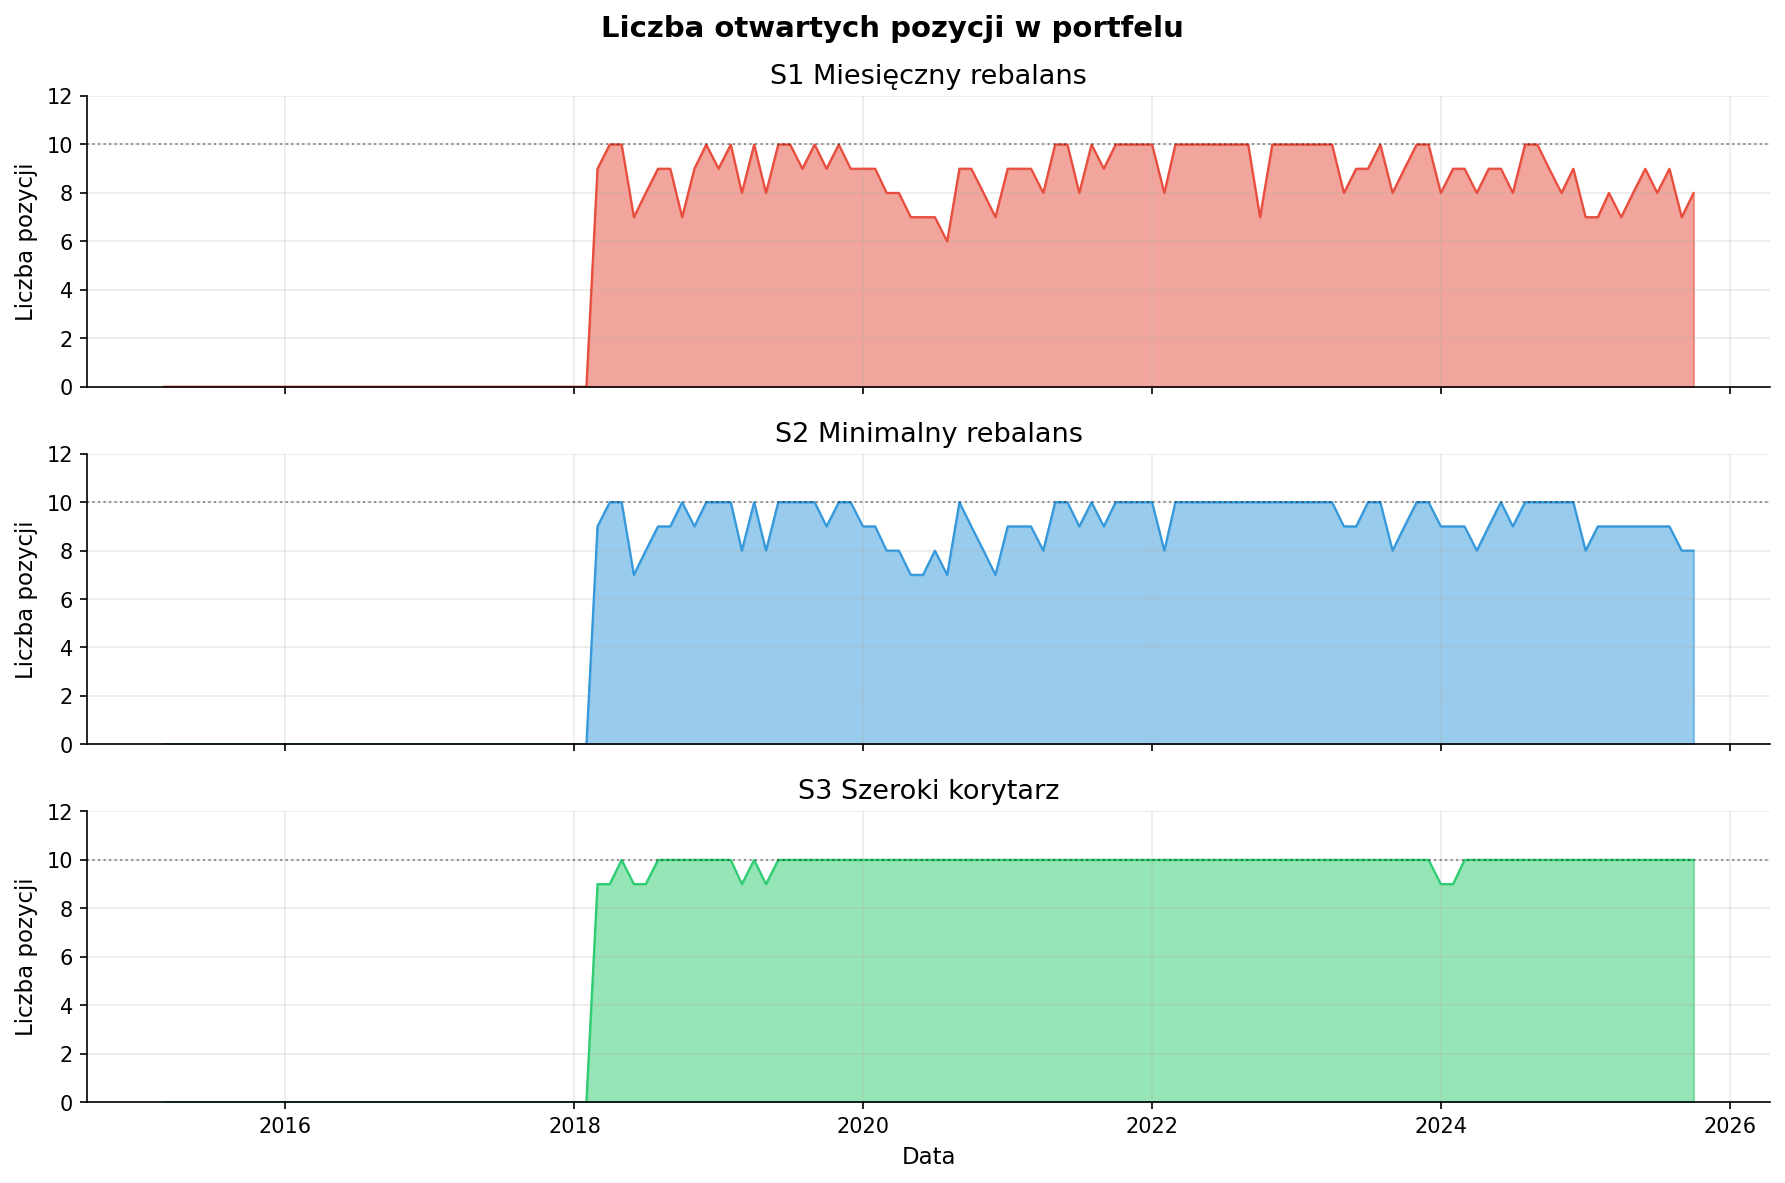

Saved: 04_liczba_pozycji.png


In [9]:
# ── Fig 4: Liczba otwartych pozycji w portfelu ─────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
col_list = [COLORS['s1'], COLORS['s2'], COLORS['s3']]

for ax, (name, res), col in zip(axes, results.items(), col_list):
    ax.fill_between(res['cap'].index, res['cap']['n_positions'], alpha=0.5, color=col)
    ax.plot(res['cap'].index, res['cap']['n_positions'], color=col, linewidth=1)
    ax.set_ylabel('Liczba pozycji')
    ax.set_ylim(0, 12)
    ax.axhline(10, color='black', linestyle=':', alpha=0.4, linewidth=1)
    ax.set_title(name)

axes[-1].set_xlabel('Data')
fig.suptitle('Liczba otwartych pozycji w portfelu', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / '04_liczba_pozycji.png', bbox_inches='tight')
plt.show()
print('Saved: 04_liczba_pozycji.png')


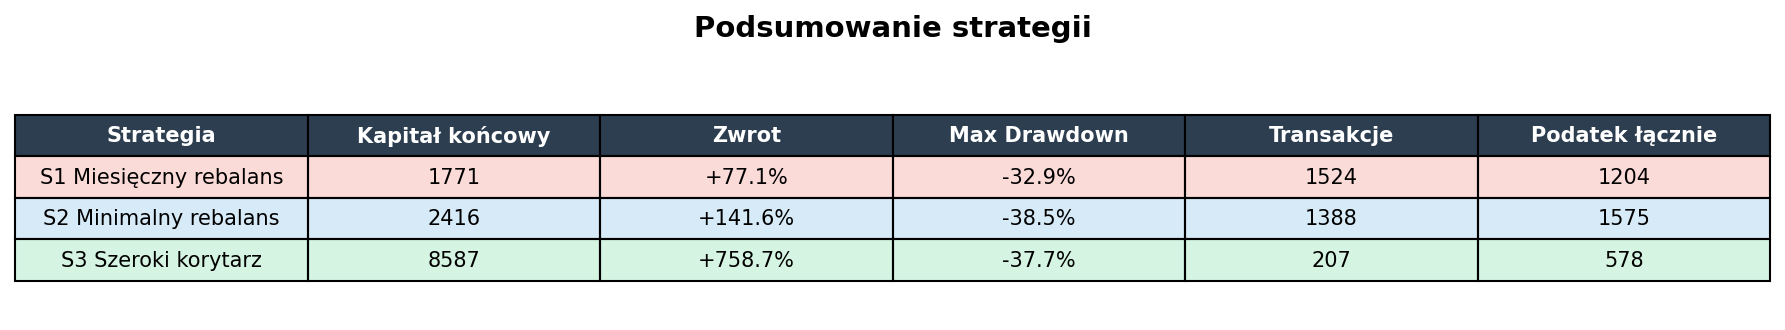

Saved: 05_tabela_podsumowanie.png


In [10]:
# ── Fig 5: Summary table ─────────────────────────────────────────────────
rows = []
for name, res in results.items():
    cap    = res['cap']['capital']
    final  = cap.iloc[-1]
    start  = res['cfg']['start_capital']
    ret    = (final / start - 1) * 100
    roll_m = cap.cummax()
    max_dd = ((cap - roll_m) / roll_m * 100).min()
    ntxn   = len(res['txn'])
    ttax   = res['tax']['tax'].sum() if not res['tax'].empty else 0
    rows.append([name, f'{final:.0f}', f'{ret:+.1f}%', f'{max_dd:.1f}%',
                 str(ntxn), f'{ttax:.0f}'])

col_labels = ['Strategia', 'Kapitał końcowy', 'Zwrot', 'Max Drawdown', 'Transakcje', 'Podatek łącznie']
fig, ax = plt.subplots(figsize=(12, 2.2))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
# header style
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
# row colors
row_colors = [COLORS['s1'], COLORS['s2'], COLORS['s3']]
for i, c in enumerate(row_colors, 1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(c + '33')  # transparent
fig.suptitle('Podsumowanie strategii', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
fig.savefig(OUT / '05_tabela_podsumowanie.png', bbox_inches='tight')
plt.show()
print('Saved: 05_tabela_podsumowanie.png')


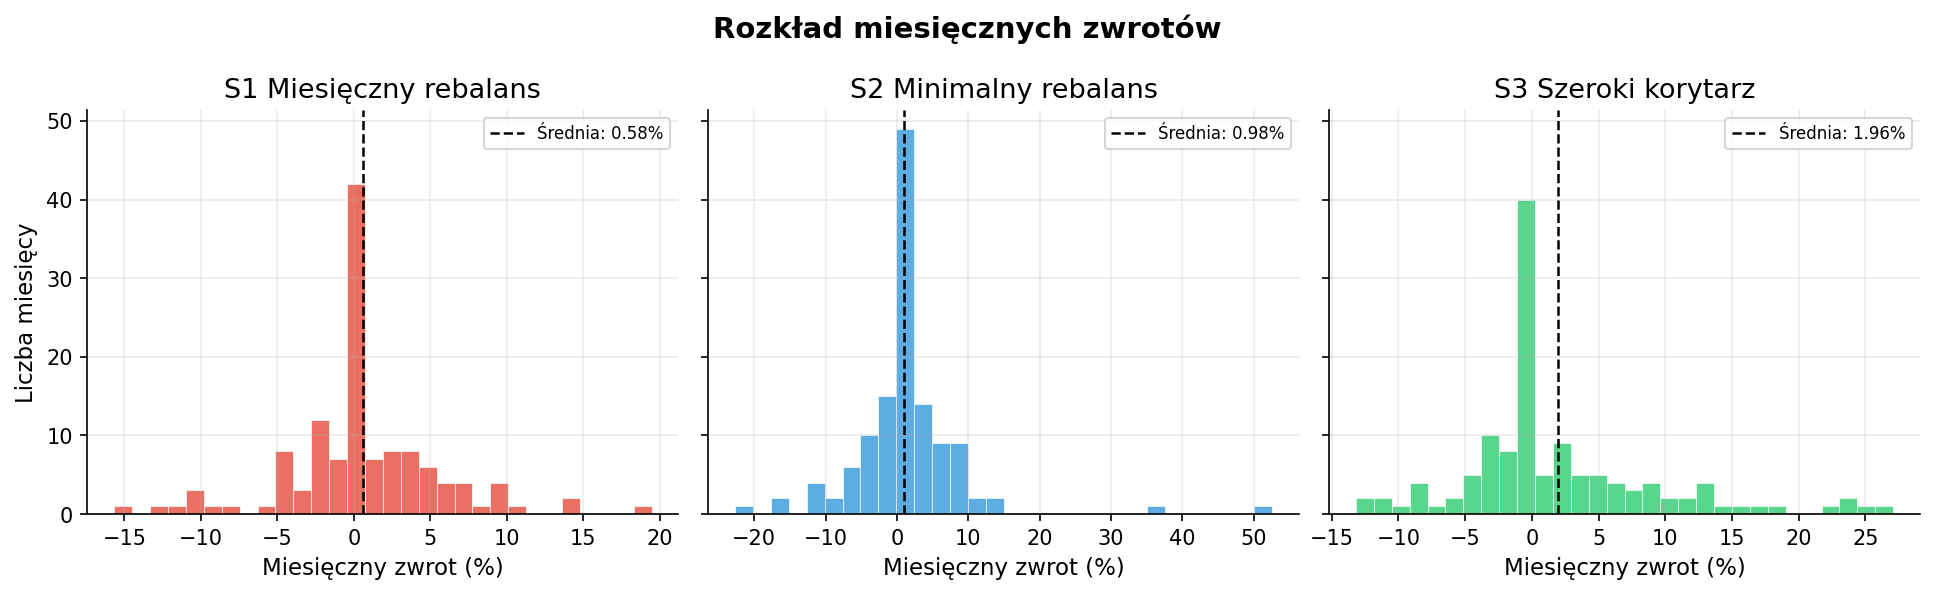

Saved: 06_rozklad_zwrotow.png


In [11]:
# ── Fig 6: Distribution of monthly portfolio returns ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
col_list = [COLORS['s1'], COLORS['s2'], COLORS['s3']]

for ax, (name, res), col in zip(axes, results.items(), col_list):
    m_ret = res['cap']['capital'].pct_change().dropna() * 100
    ax.hist(m_ret, bins=30, color=col, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.axvline(m_ret.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Średnia: {m_ret.mean():.2f}%')
    ax.set_title(name)
    ax.set_xlabel('Miesięczny zwrot (%)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Liczba miesięcy')
fig.suptitle('Rozkład miesięcznych zwrotów', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / '06_rozklad_zwrotow.png', bbox_inches='tight')
plt.show()
print('Saved: 06_rozklad_zwrotow.png')


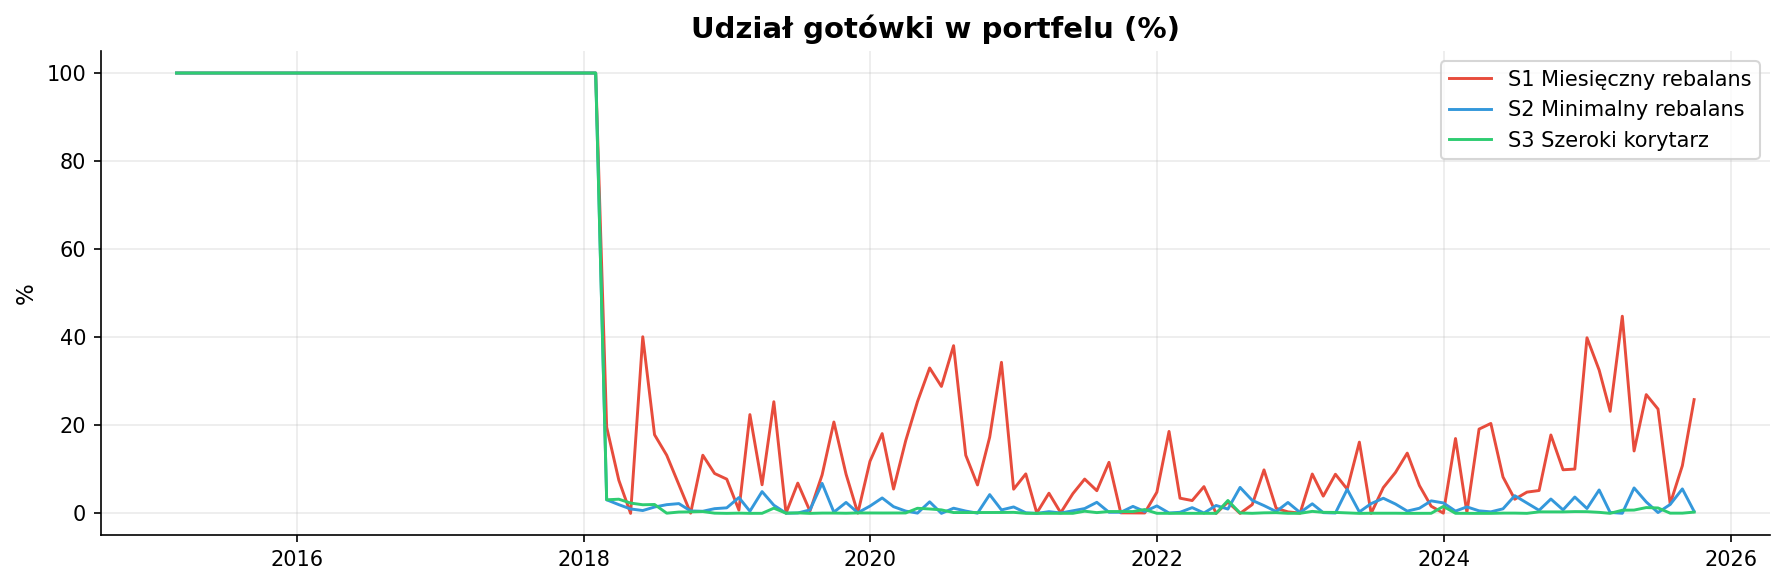

Saved: 07_udzial_gotowki.png


In [12]:
# ── Fig 7: Cash allocation in portfolio ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
col_list = [COLORS['s1'], COLORS['s2'], COLORS['s3']]

for (name, res), col in zip(results.items(), col_list):
    cash_pct = res['cap']['cash'] / res['cap']['capital'] * 100
    ax.plot(res['cap'].index, cash_pct, label=name, color=col, linewidth=1.4)

ax.set_title('Udział gotówki w portfelu (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('%')
ax.legend()
plt.tight_layout()
fig.savefig(OUT / '07_udzial_gotowki.png', bbox_inches='tight')
plt.show()
print('Saved: 07_udzial_gotowki.png')


## 6. Animation — Capital Growth Over Time

Animation compares capital of all three strategies month by month.
Ideal for YouTube Shorts or as a video intro.

In [13]:
# ── Animation: portfolio capital month by month ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(price_m.index[0], price_m.index[-1])

all_vals = pd.concat([r['cap']['capital'] for r in results.values()])
ax.set_ylim(all_vals.min() * 0.9, all_vals.max() * 1.1)
ax.axhline(1000, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax.set_xlabel('Data')
ax.set_ylabel('Kapitał (PLN)')
ax.set_title('Strategia wzrostowa GPW — symulacja 2015–2025', fontsize=13, fontweight='bold')

names = list(results.keys())
col_list = [COLORS['s1'], COLORS['s2'], COLORS['s3']]
caps = [results[n]['cap']['capital'] for n in names]
dates = caps[0].index

lines = [ax.plot([], [], color=c, linewidth=2, label=n)[0]
         for n, c in zip(names, col_list)]
dots  = [ax.plot([], [], 'o', color=c, markersize=6)[0] for c in col_list]
labels= [ax.text(0, 0, '', color=c, fontsize=9, fontweight='bold') for c in col_list]
date_txt = ax.text(0.02, 0.95, '', transform=ax.transAxes,
                   fontsize=11, color='#555', va='top')
ax.legend(loc='upper left', fontsize=9)

STEP = 2  # animate every 2nd month for speed
frames = range(1, len(dates), STEP)

def animate(i):
    for line, dot, lbl, cap in zip(lines, dots, labels, caps):
        x = dates[:i]
        y = cap.iloc[:i]
        line.set_data(x, y)
        dot.set_data([dates[i-1]], [cap.iloc[i-1]])
        lbl.set_position((dates[i-1], cap.iloc[i-1]*1.02))
        lbl.set_text(f'{cap.iloc[i-1]:.0f}')
    date_txt.set_text(dates[i-1].strftime('%b %Y'))
    return lines + dots + labels + [date_txt]

anim = animation.FuncAnimation(fig, animate, frames=frames,
                                interval=80, blit=True)

# Save as MP4 (YouTube) + GIF (article/web)
anim.save(OUT / 'animacja_kapital.mp4', writer='ffmpeg', fps=15,
          extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
print('Saved: animacja_kapital.mp4')

anim.save(OUT / 'animacja_kapital.gif', writer='pillow', fps=12)
print('Saved: animacja_kapital.gif')

plt.close()
print('Animacja gotowa!')


Saved: animacja_kapital.mp4


Saved: animacja_kapital.gif
Animacja gotowa!


## 7. Export Results to CSV

In [14]:
for name, res in results.items():
    slug = name.replace(' ', '_').lower()
    res['cap'].to_csv(OUT / f'{slug}_kapital.csv')
    if not res['txn'].empty:
        res['txn'].to_csv(OUT / f'{slug}_transakcje.csv', index=False)
    print(f'Saved: {slug}_kapital.csv  |  {slug}_transakcje.csv')

print('\n--- Wszystkie pliki w folderze charts/ ---')
import os
for f in sorted(os.listdir(OUT)): print(' ', f)


Saved: s1_miesięczny_rebalans_kapital.csv  |  s1_miesięczny_rebalans_transakcje.csv
Saved: s2_minimalny_rebalans_kapital.csv  |  s2_minimalny_rebalans_transakcje.csv
Saved: s3_szeroki_korytarz_kapital.csv  |  s3_szeroki_korytarz_transakcje.csv

--- Wszystkie pliki w folderze charts/ ---
  01_kapital_porownanie.png
  02_podatki_roczne.png
  03_drawdown.png
  04_liczba_pozycji.png
  05_tabela_podsumowanie.png
  06_rozklad_zwrotow.png
  07_udzial_gotowki.png
  animacja_kapital.gif
  animacja_kapital.mp4
  s1_miesięczny_rebalans_kapital.csv
  s1_miesięczny_rebalans_transakcje.csv
  s2_minimalny_rebalans_kapital.csv
  s2_minimalny_rebalans_transakcje.csv
  s3_szeroki_korytarz_kapital.csv
  s3_szeroki_korytarz_transakcje.csv
